In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.5888 - loss: 0.6672 - val_accuracy: 0.6160 - val_loss: 0.6486
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6594 - loss: 0.6131 - val_accuracy: 0.6760 - val_loss: 0.5956
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6948 - loss: 0.5724 - val_accuracy: 0.6910 - val_loss: 0.5878
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7181 - loss: 0.5464 - val_accuracy: 0.7080 - val_loss: 0.5723
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7425 - loss: 0.5144 - val_accuracy: 0.7130 - val_loss: 0.5611
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7569 - loss: 0.4960 - val_accuracy: 0.7050 - val_loss: 0.5610
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7631 - loss: 0.4788 - val_accuracy: 0.7255 - val_loss: 0.5566
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7834 - loss: 0.4481 - val_acc

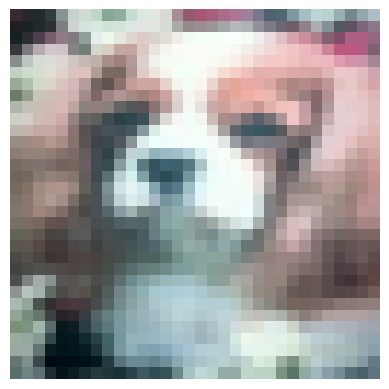

In [ ]:

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

train_filter = np.where((y_train == 3) | (y_train == 5))[0]
test_filter  = np.where((y_test  == 3) | (y_test  == 5))[0]
x_train,y_train=x_train[train_filter], y_train[train_filter]
x_test,y_test=x_test[test_filter], y_test[test_filter]
y_train=(y_train==5).astype(int)
y_test=(y_test==5).astype(int)
x_train=x_train/255.0
x_test=x_test/255.0
model=Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history=model.fit(x_train,y_train,epochs=10,batch_size=64, validation_split=0.2)
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f" test accuray is {test_acc:.4f}" )
index=np.random.randint(0,len(x_test))
img=x_test[index]
label=y_test[index]
plt.imshow(img)
plt.axis("off")
img = np.expand_dims(img, axis=0)
prediction = model.predict(img)
if prediction[0][0] > 0.5:
    print("it is a dog")
else:
    print("it is a cat")
print(" Actual label:", "Dog" if label == 1 else "Cat")